Colab: **`DIPLOM_DRIVE_DIR`**, исходный parquet, `Прогон всех моделек/exps/generate_peak_experiments.py`.

Результат на Drive: папка **`OUTPUT_DIR_NAME`** → подпапки **`k=0`**, **`k=1`**, … с parquet **только метаданные** (все колонки кроме недельных). По ним потом отбираете `id`/`keyword` и подмешиваете ряды из исходного файла.

**Чекпоинт** `checkpoint.json`: при обрыве перезапустите ячейку — продолжит с последней позиции `(row_group, row_in_row_group)`.

**Прогресс**: `tqdm` (`file=sys.stdout`). Если полосы не видно — в Colab включите вывод и смотрите счётчик `n/total` и postfix.

**С нуля**: удалите папку **`OUTPUT_DIR_NAME`** на Drive (или смените имя в коде), иначе `part-*.parquet` могут дописаться поверх логики счётчика при потере `checkpoint.json`.

In [ ]:
import contextlib
import json
import multiprocessing as mp
import os
import re
import sys
import time
import warnings
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from google.colab import drive
from tqdm.auto import tqdm

DIPLOM_DRIVE_DIR = "/content/drive/MyDrive/Диплом"
OUTPUT_DIR_NAME = "peak_groups_by_k"
MAX_ROWS = None
N_WORKERS = min(16, os.cpu_count() or 8)
ROWS_PER_TASK = 2500
INTRA_BATCH = 20_000
FLUSH_BUFFER_ROWS = 80_000

if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")

DIPLOM = Path(DIPLOM_DRIVE_DIR)
DATA_PATH = DIPLOM / "dataset_without_non_empty_lt26.parquet"
EXPS_DIR = DIPLOM / "Прогон всех моделек" / "exps"
OUT_ROOT = DIPLOM / OUTPUT_DIR_NAME
CKPT_PATH = OUT_ROOT / "checkpoint.json"

sys.path.insert(0, str(EXPS_DIR))
if not DATA_PATH.is_file():
    raise FileNotFoundError(DATA_PATH)
if not (EXPS_DIR / "generate_peak_experiments.py").is_file():
    raise FileNotFoundError(EXPS_DIR / "generate_peak_experiments.py")
os.environ["DIPLOM_EXPS_DIR"] = str(EXPS_DIR)

from generate_peak_experiments import run_detection_pipeline

_NUM = {
    pa.int8(), pa.int16(), pa.int32(), pa.int64(),
    pa.uint8(), pa.uint16(), pa.uint32(), pa.uint64(),
    pa.float16(), pa.float32(), pa.float64(),
}
_SKIP = {"id", "series_id", "keyword_id"}


def _prep(a: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=np.float64)
    if np.isfinite(a).all():
        return a
    s = pd.Series(a)
    return s.interpolate(limit_direction="both").bfill().ffill().fillna(0.0).to_numpy(dtype=np.float64)


_WK = None


def _mp_init() -> None:
    global _WK
    import os as O
    import sys as S

    p = O.environ["DIPLOM_EXPS_DIR"]
    if p not in S.path:
        S.path.insert(0, p)
    import generate_peak_experiments as g

    _WK = g.run_detection_pipeline


def _worker_k_array(block: np.ndarray) -> np.ndarray:
    out = np.empty(block.shape[0], dtype=np.int16)
    for i in range(block.shape[0]):
        try:
            out[i] = int(len(_WK(_prep(block[i]))["groups"]))
        except Exception:
            out[i] = -1
    return out


def _weekly_cols(names: list[str]) -> list[str]:
    cols = pd.Index(names)
    wp = re.compile(r"^(week|wk)[_\- ]?\d+$", re.IGNORECASE)
    by_pat = [c for c in cols if isinstance(c, str) and wp.match(c)]
    rest = [c for c in cols if isinstance(c, str) and c not in by_pat]
    if not rest:
        by_dt: list = []
    else:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            idx = pd.Index(rest)
            try:
                dt = pd.to_datetime(idx, errors="coerce", dayfirst=False, format="mixed")
            except (TypeError, ValueError):
                dt = pd.to_datetime(idx, errors="coerce", dayfirst=False)
        by_dt = [c for c, t in zip(rest, dt) if pd.notna(t)]
    return list(dict.fromkeys(by_dt + by_pat))


def _time_cols(pf: pq.ParquetFile) -> list[str]:
    w = _weekly_cols(list(pf.schema_arrow.names))
    if len(w) >= 10:
        return w
    out = [f.name for f in pf.schema_arrow if f.type in _NUM and f.name.lower() not in _SKIP]
    if not out:
        raise ValueError("Нет числовых колонок ряда")
    return out


def _atomic_write_json(path: Path, data: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(".json.tmp")
    tmp.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")
    tmp.replace(path)


def _load_ckpt() -> dict:
    if not CKPT_PATH.is_file():
        return {
            "next_row_group": 0,
            "next_row_in_row_group": 0,
            "part_counter": {},
            "rows_done_total": 0,
            "counts": {},
            "n_err": 0,
        }
    return json.loads(CKPT_PATH.read_text(encoding="utf-8"))


def _flush_bufs(bufs: dict[int, list], part_counter: dict[int, int]) -> None:
    for k, rows in list(bufs.items()):
        if not rows:
            continue
        sub = OUT_ROOT / f"k={k}"
        sub.mkdir(parents=True, exist_ok=True)
        n = part_counter.get(k, 0)
        fp = sub / f"part-{n:06d}.parquet"
        pd.DataFrame(rows).to_parquet(fp, index=False, engine="pyarrow")
        part_counter[k] = n + 1
        bufs[k].clear()


OUT_ROOT.mkdir(parents=True, exist_ok=True)
pf = pq.ParquetFile(DATA_PATH)
time_cols = _time_cols(pf)
all_names = list(pf.schema_arrow.names)
meta_cols = [c for c in all_names if c not in set(time_cols)]
read_cols = meta_cols + time_cols

pm = pf.metadata
n_file = int(pm.num_rows) if pm is not None and pm.num_rows is not None else None
pbar_total = (
    min(MAX_ROWS, n_file)
    if (MAX_ROWS is not None and n_file is not None)
    else (MAX_ROWS if MAX_ROWS is not None else n_file)
)

st = _load_ckpt()
start_rg = int(st["next_row_group"])
start_i = int(st["next_row_in_row_group"])
part_counter = defaultdict(int)
for kk, vv in st.get("part_counter", {}).items():
    part_counter[int(kk)] = int(vv)
rows_done_total = int(st.get("rows_done_total", 0))
counts = Counter({int(k): int(v) for k, v in st.get("counts", {}).items()})
n_err = int(st.get("n_err", 0))

if start_rg >= pf.num_row_groups:
    print("По checkpoint файл уже обработан целиком. Для нового прогона удалите", OUT_ROOT)

bufs: dict[int, list] = defaultdict(list)
buf_rows = 0
t0 = time.perf_counter()

_ctx = (
    contextlib.nullcontext(None)
    if N_WORKERS <= 1
    else ProcessPoolExecutor(
        max_workers=N_WORKERS,
        mp_context=mp.get_context("fork"),
        initializer=_mp_init,
    )
)

with _ctx as ex:
    _pbar_init = min(rows_done_total, pbar_total) if pbar_total is not None else rows_done_total
    bar = tqdm(
        total=pbar_total,
        initial=_pbar_init,
        unit="row",
        desc="rows",
        file=sys.stdout,
        dynamic_ncols=True,
        mininterval=0.5,
        smoothing=0.05,
    )
    try:
        for rg in range(start_rg, pf.num_row_groups):
            t_rg = time.perf_counter()
            tbl = pf.read_row_group(rg, columns=read_cols)
            nrg = tbl.num_rows
            i0 = start_i if rg == start_rg else 0
            start_i = 0
            j = i0
            while j < nrg:
                if MAX_ROWS is not None and rows_done_total >= MAX_ROWS:
                    break
                j1 = min(j + INTRA_BATCH, nrg)
                if MAX_ROWS is not None:
                    left = MAX_ROWS - rows_done_total
                    if left <= 0:
                        break
                    j1 = min(j1, j + left)
                if j1 <= j:
                    break
                sub = tbl.slice(j, j1 - j)
                df = sub.to_pandas()
                meta = df[meta_cols]
                arr = df[time_cols].to_numpy(dtype=np.float64, copy=False)
                n_here = arr.shape[0]
                ks = np.empty(n_here, dtype=np.int16)
                use_mp = ex is not None and n_here >= max(ROWS_PER_TASK * 2, 2)
                if use_mp:
                    tasks = [np.ascontiguousarray(arr[i : i + ROWS_PER_TASK].copy()) for i in range(0, n_here, ROWS_PER_TASK)]
                    cs = max(1, len(tasks) // max(N_WORKERS * 8, 1))
                    pos = 0
                    for part in ex.map(_worker_k_array, tasks, chunksize=cs):
                        part = np.asarray(part, dtype=np.int16).ravel()
                        ks[pos : pos + part.size] = part
                        pos += part.size
                    if pos != n_here:
                        raise RuntimeError(f"parallel k len {pos} != {n_here}")
                    n_err += int((ks < 0).sum())
                else:
                    for ii in range(n_here):
                        try:
                            ks[ii] = int(len(run_detection_pipeline(_prep(arr[ii]))["groups"]))
                        except Exception:
                            ks[ii] = -1
                            n_err += 1
                for ii in range(n_here):
                    k = int(ks[ii])
                    counts[k] += 1
                    bufs[k].append(meta.iloc[ii].to_dict())
                buf_rows += n_here
                rows_done_total += n_here
                bar.update(n_here)
                j = j1
                if buf_rows >= FLUSH_BUFFER_ROWS:
                    _flush_bufs(bufs, part_counter)
                    buf_rows = 0
                    _atomic_write_json(
                        CKPT_PATH,
                        {
                            "next_row_group": rg,
                            "next_row_in_row_group": j,
                            "part_counter": {str(k): int(v) for k, v in part_counter.items()},
                            "rows_done_total": rows_done_total,
                            "counts": {str(k): int(v) for k, v in counts.items()},
                            "n_err": n_err,
                        },
                    )
                bar.set_postfix_str(
                    f"rg{rg+1}/{pf.num_row_groups} j{j}/{nrg} err{n_err} {time.perf_counter()-t_rg:.0f}s",
                    refresh=False,
                )
            del tbl
            _flush_bufs(bufs, part_counter)
            buf_rows = 0
            _ck = {
                "part_counter": {str(k): int(v) for k, v in part_counter.items()},
                "rows_done_total": rows_done_total,
                "counts": {str(k): int(v) for k, v in counts.items()},
                "n_err": n_err,
            }
            if j >= nrg:
                _ck["next_row_group"] = rg + 1
                _ck["next_row_in_row_group"] = 0
            else:
                _ck["next_row_group"] = rg
                _ck["next_row_in_row_group"] = j
            _atomic_write_json(CKPT_PATH, _ck)
            if MAX_ROWS is not None and rows_done_total >= MAX_ROWS:
                break
    finally:
        bar.close()

summary = pd.DataFrame([{"k": k, "n_series": v, "share": v / max(rows_done_total, 1)} for k, v in sorted(counts.items())])
print("OUT_ROOT", OUT_ROOT)
print("parquet_num_rows", n_file, "rows_done_total", rows_done_total, "err", n_err, "s", round(time.perf_counter() - t0, 1))
print(summary.to_string(index=False))


Mounted at /content/drive


rows:   0%|          | 0/10697265 [00:00<?, ?row/s]

OUT_ROOT /content/drive/MyDrive/Диплом/peak_groups_by_k
parquet_num_rows 10697265 rows_done_total 10697265 err 0 s 26760.6
 k  n_series    share
 0    318296 0.029755
 1   1028555 0.096151
 2   1502485 0.140455
 3   1402841 0.131140
 4   1024539 0.095776
 5    860456 0.080437
 6   1040997 0.097314
 7   1268863 0.118616
 8   1152892 0.107774
 9    713457 0.066695
10    293003 0.027390
11     77077 0.007205
12     12523 0.001171
13      1227 0.000115
14        54 0.000005


OUT_ROOT: /content/drive/MyDrive/Диплом/peak_groups_by_k
DATA_PATH: /content/drive/MyDrive/Диплом/dataset_without_non_empty_lt26.parquet
k=1: part-files=265
k=1: sampled=5
k=2: part-files=265
k=2: sampled=5
k=3: part-files=265
k=3: sampled=5
key_cols_global: ['Keyword']
target keys: 15
found series: 15 of 15
render k=1, plotted=5


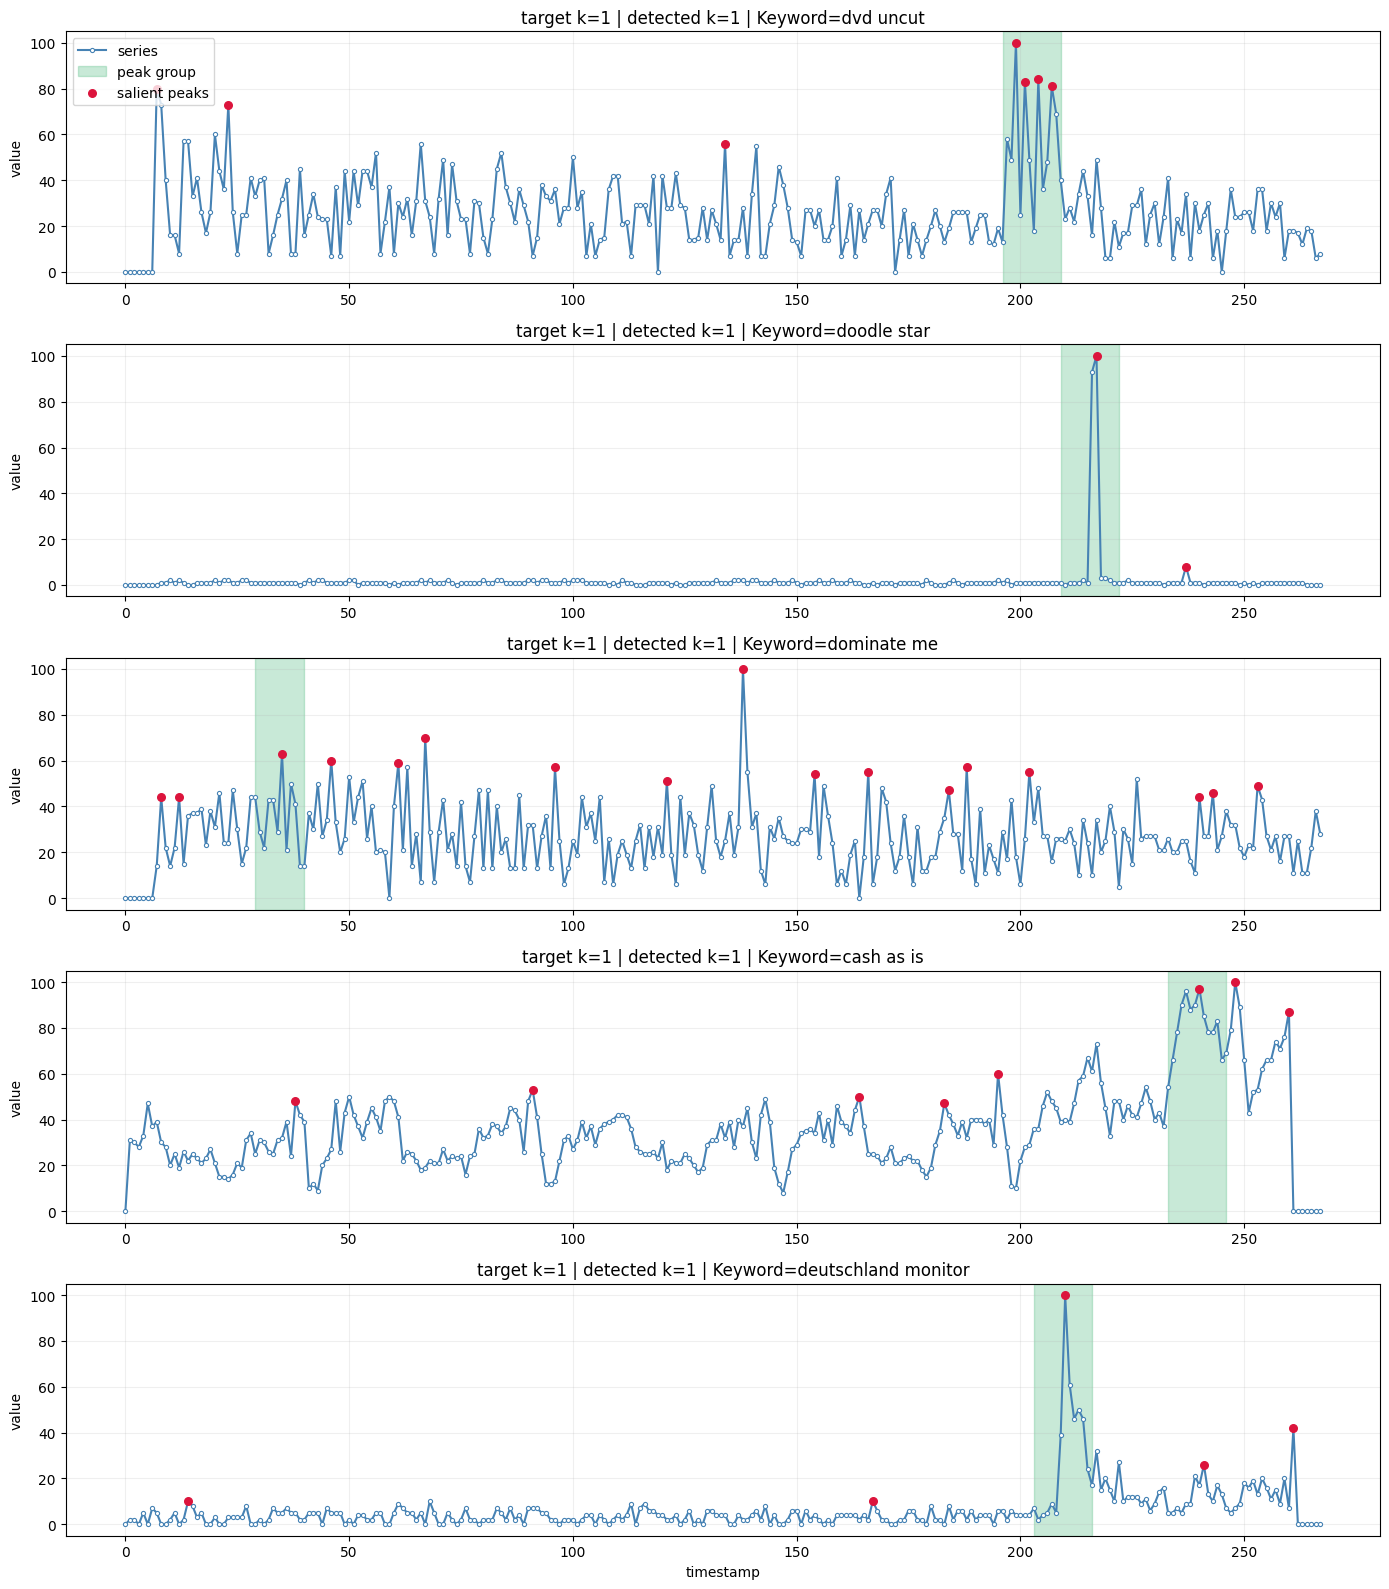

render k=2, plotted=5


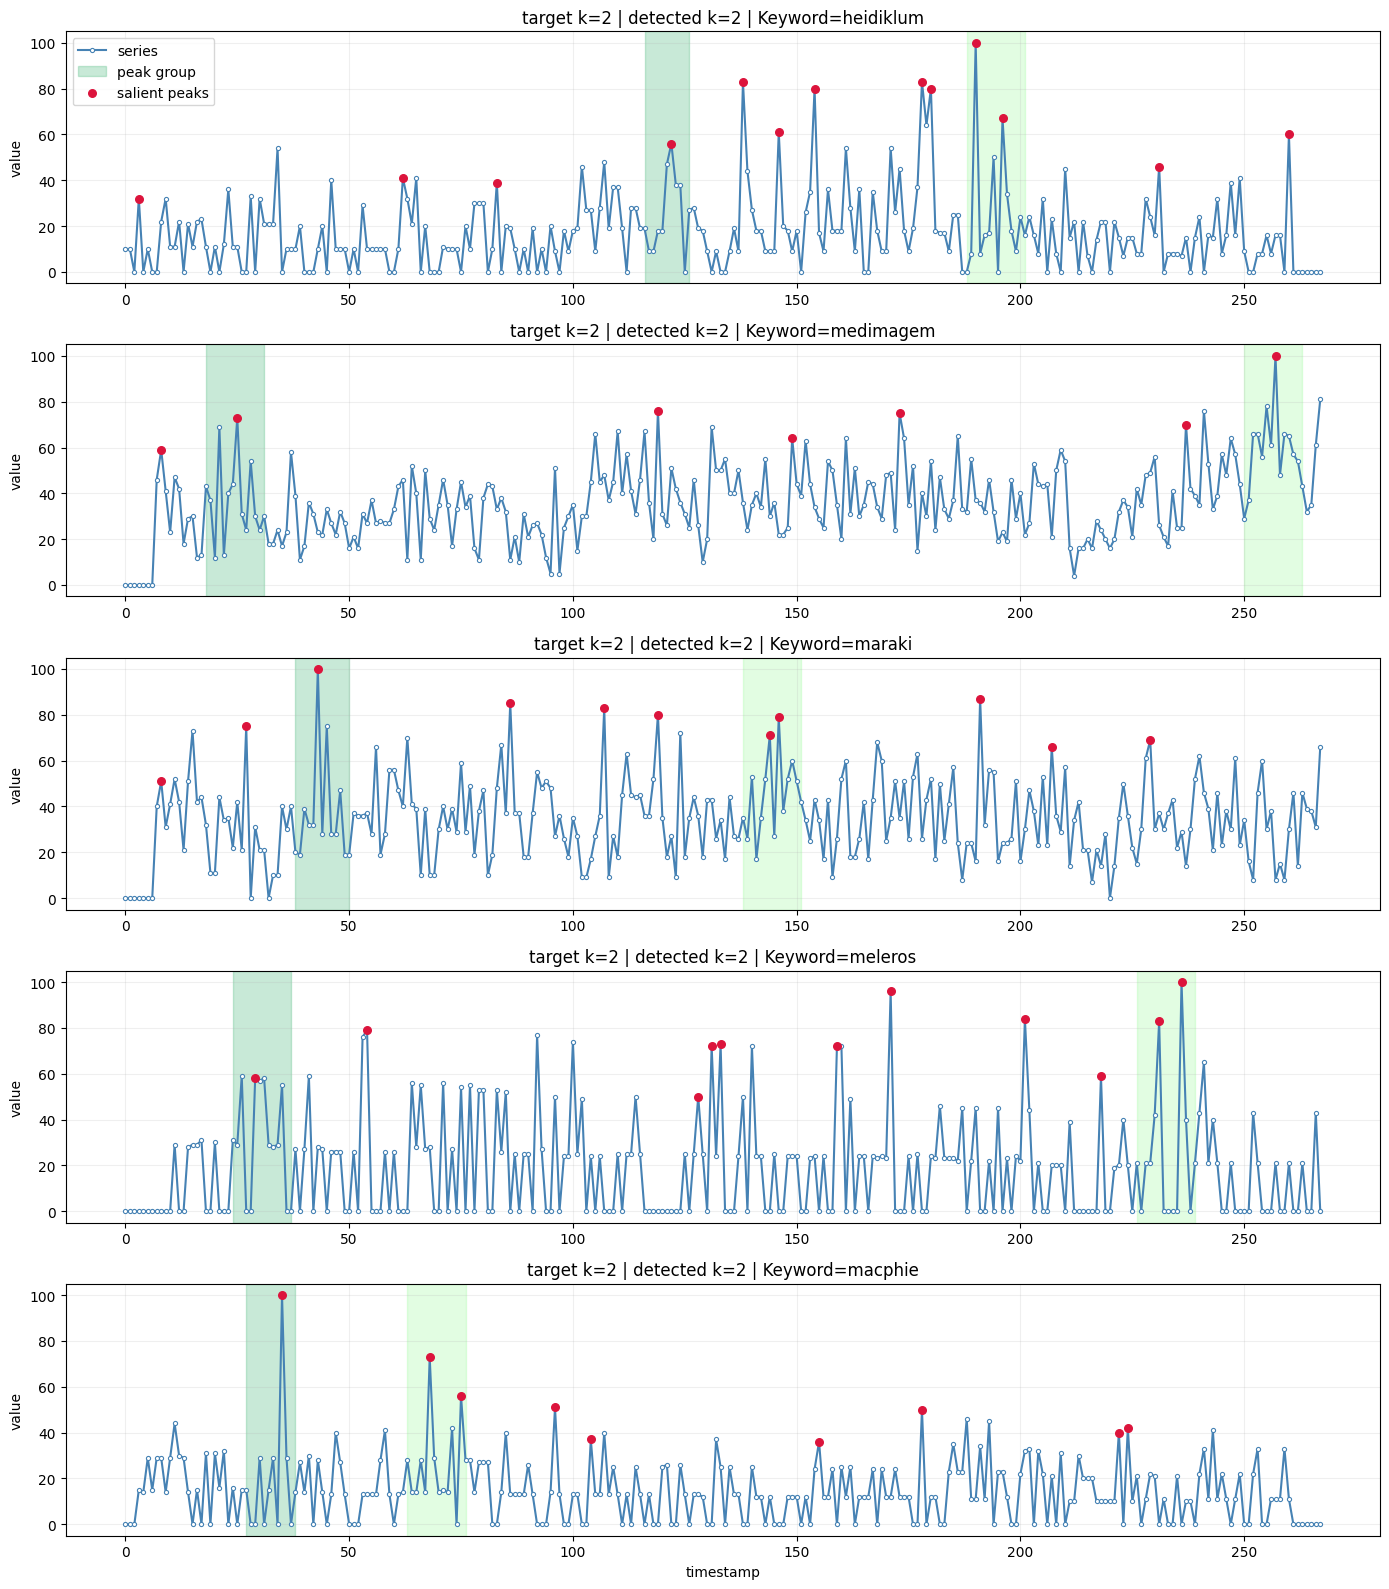

render k=3, plotted=5


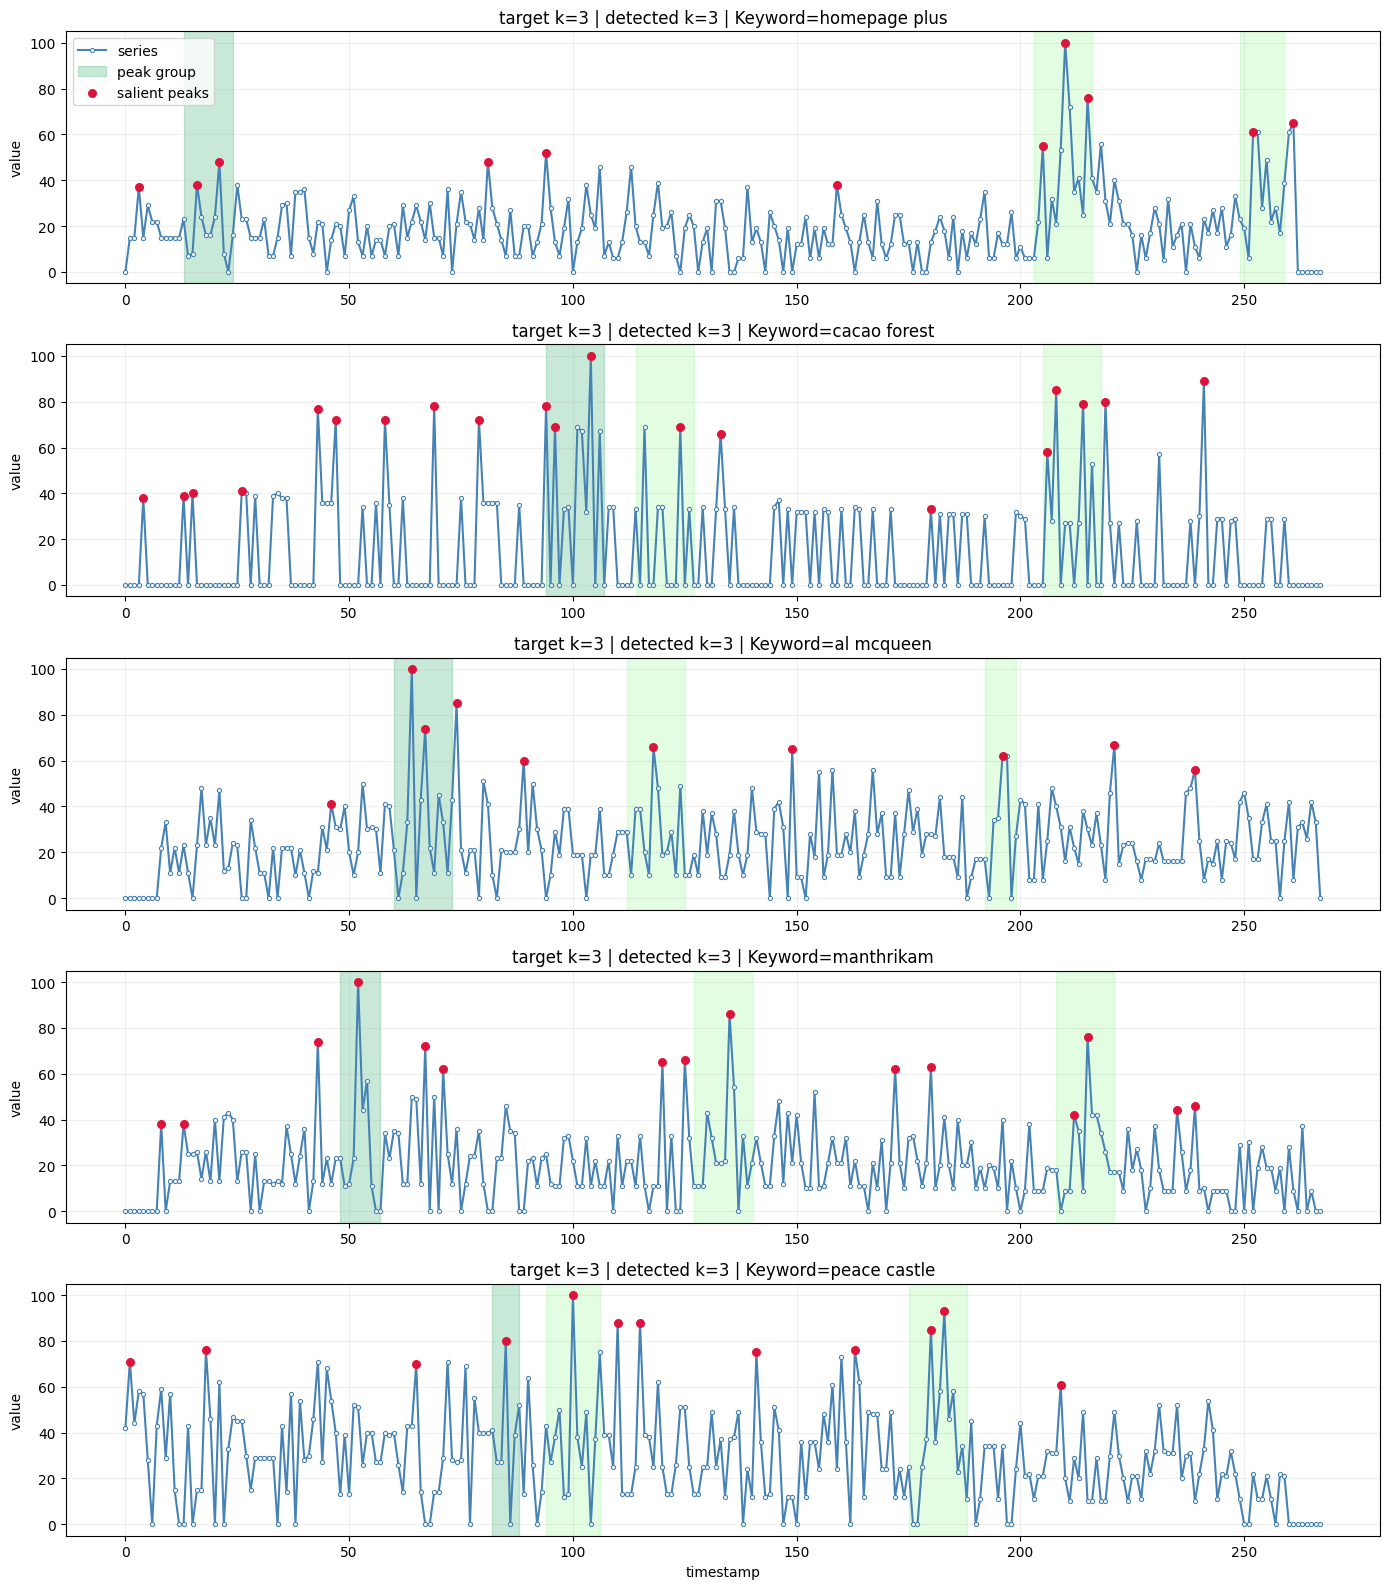

In [ ]:
import matplotlib.pyplot as plt

SAMPLE_PER_K = 5
PLOT_KS = [1, 2, 3]
RANDOM_STATE = 42
MAX_PART_FILES_PER_K = 30

try:
    _ = DATA_PATH
    _ = OUT_ROOT
    _ = time_cols
except NameError:
    DIPLOM = Path(DIPLOM_DRIVE_DIR)
    DATA_PATH = DIPLOM / "dataset_without_non_empty_lt26.parquet"
    OUT_ROOT = DIPLOM / OUTPUT_DIR_NAME
    pf_tmp = pq.ParquetFile(DATA_PATH)
    time_cols = _time_cols(pf_tmp)

if not OUT_ROOT.is_dir():
    raise FileNotFoundError(f"Не найдена папка с результатами: {OUT_ROOT}")

print(f"OUT_ROOT: {OUT_ROOT}")
print(f"DATA_PATH: {DATA_PATH}")


def _build_key_cols(df_cols: list[str]) -> list[str]:
    preferred = ["keyword_id", "series_id", "id", "keyword", "query", "word"]
    out = [c for c in preferred if c in df_cols]
    if not out:
        out = [c for c in df_cols if c not in {"k", "n_green_peak_groups"}][:3]
    return out


sampled_meta_by_k: dict[int, pd.DataFrame] = {}
all_keys: set[tuple[str, ...]] = set()
key_cols_global: list[str] | None = None

for k in PLOT_KS:
    k_dir = OUT_ROOT / f"k={k}"
    part_files = sorted(k_dir.glob("part-*.parquet")) if k_dir.is_dir() else []
    print(f"k={k}: part-files={len(part_files)}")
    if not part_files:
        sampled_meta_by_k[k] = pd.DataFrame()
        continue

    # Берем не все файлы, а равномерно подвыборку, чтобы не упираться в память/время.
    if len(part_files) > MAX_PART_FILES_PER_K:
        idx = np.linspace(0, len(part_files) - 1, MAX_PART_FILES_PER_K, dtype=int)
        part_files = [part_files[i] for i in idx]

    frames = []
    for fp in part_files:
        try:
            d = pd.read_parquet(fp)
            if not d.empty:
                frames.append(d)
        except Exception as e:
            print(f"k={k}: skip unreadable {fp.name}: {e}")

    if not frames:
        print(f"k={k}: не удалось прочитать part-файлы")
        sampled_meta_by_k[k] = pd.DataFrame()
        continue

    meta_k = pd.concat(frames, ignore_index=True)
    key_cols = _build_key_cols(meta_k.columns.tolist())
    if not key_cols:
        print(f"k={k}: не удалось определить ключевые колонки")
        sampled_meta_by_k[k] = pd.DataFrame()
        continue

    if key_cols_global is None:
        key_cols_global = key_cols
    else:
        key_cols_global = [c for c in key_cols_global if c in key_cols]

    n_take = min(SAMPLE_PER_K, len(meta_k))
    sampled = meta_k.sample(n_take, random_state=RANDOM_STATE).reset_index(drop=True)
    sampled_meta_by_k[k] = sampled
    print(f"k={k}: sampled={len(sampled)}")

if key_cols_global is None or not key_cols_global:
    raise ValueError("Нет ключевых колонок для матчинга с исходным parquet")

print("key_cols_global:", key_cols_global)

for k in PLOT_KS:
    sm = sampled_meta_by_k.get(k, pd.DataFrame())
    if sm.empty:
        continue
    missing = [c for c in key_cols_global if c not in sm.columns]
    if missing:
        print(f"k={k}: пропуск (нет ключей {missing})")
        sampled_meta_by_k[k] = pd.DataFrame()
        continue
    for _, r in sm[key_cols_global].iterrows():
        all_keys.add(tuple(str(r[c]) for c in key_cols_global))

print("target keys:", len(all_keys))
if not all_keys:
    raise ValueError("Нет ключей для извлечения рядов из исходного parquet")


pf_src = pq.ParquetFile(DATA_PATH)
read_cols_plot = key_cols_global + time_cols
series_by_key: dict[tuple[str, ...], np.ndarray] = {}

for rg in range(pf_src.num_row_groups):
    df_rg = pf_src.read_row_group(rg, columns=read_cols_plot).to_pandas()
    if df_rg.empty:
        continue
    key_tuples = df_rg[key_cols_global].astype(str).apply(lambda x: tuple(x.values.tolist()), axis=1)
    mask = key_tuples.isin(all_keys)
    if not mask.any():
        continue

    hit = df_rg.loc[mask]
    for _, row in hit.iterrows():
        key = tuple(str(row[c]) for c in key_cols_global)
        if key not in series_by_key:
            series_by_key[key] = _prep(row[time_cols].to_numpy(dtype=np.float64, copy=False))

    if len(series_by_key) >= len(all_keys):
        break

print("found series:", len(series_by_key), "of", len(all_keys))

any_drawn = False
for k in PLOT_KS:
    sm = sampled_meta_by_k.get(k, pd.DataFrame())
    if sm.empty:
        print(f"k={k}: нечего рисовать")
        continue

    fig, axes = plt.subplots(len(sm), 1, figsize=(14, 3.2 * len(sm)), sharex=False)
    if len(sm) == 1:
        axes = [axes]

    drawn = 0
    for ax, (_, meta_row) in zip(axes, sm.iterrows()):
        key = tuple(str(meta_row[c]) for c in key_cols_global)
        values = series_by_key.get(key)
        if values is None:
            ax.set_title(f"k={k} | ключ не найден в исходном parquet")
            ax.axis("off")
            continue

        out = run_detection_pipeline(values)
        groups = out["groups"]
        salient = out["salient_peaks"]

        x = np.arange(values.size)
        ax.plot(x, values, color="steelblue", linewidth=1.5, marker="o", markersize=3,
                markerfacecolor="white", markeredgewidth=0.8, label="series")

        for gi, g in enumerate(groups):
            color = "mediumseagreen" if gi == 0 else "palegreen"
            label = "peak group" if gi == 0 else None
            ax.axvspan(g.start, g.end, color=color, alpha=0.28, label=label, zorder=1)

        if len(salient):
            ax.scatter(salient, values[salient], color="crimson", s=30, zorder=3, label="salient peaks")

        key_text = " | ".join([f"{c}={meta_row[c]}" for c in key_cols_global])
        ax.set_title(f"target k={k} | detected k={len(groups)} | {key_text}")
        ax.set_ylabel("value")
        ax.grid(alpha=0.2)
        if drawn == 0:
            ax.legend(loc="upper left")
        drawn += 1

    axes[-1].set_xlabel("timestamp")
    fig.tight_layout()
    print(f"render k={k}, plotted={drawn}")
    display(fig)
    plt.close(fig)
    any_drawn = any_drawn or (drawn > 0)

if not any_drawn:
    print("Графики не построены. Проверьте сообщения выше: обычно причина в пустых k=1/2/3 или несовпадении ключей.")


In [ ]:

from collections import Counter
from tqdm.auto import tqdm

MAX_ALLOWED = 180.0
CONSEC_WEEKS = 6

try:
    _ = DATA_PATH
    _ = OUT_ROOT
    _ = time_cols
except NameError:
    DIPLOM = Path(DIPLOM_DRIVE_DIR)
    DATA_PATH = DIPLOM / "dataset_without_non_empty_lt26.parquet"
    OUT_ROOT = DIPLOM / OUTPUT_DIR_NAME
    pf_tmp = pq.ParquetFile(DATA_PATH)
    time_cols = _time_cols(pf_tmp)

if not OUT_ROOT.is_dir():
    raise FileNotFoundError(f"Не найдена папка с разметкой по k: {OUT_ROOT}")


def _pick_key_cols_from_k_parts(root: Path) -> list[str]:
    preferred = ["keyword_id", "series_id", "id", "Keyword", "keyword", "query", "word"]
    for k_dir in sorted(root.glob("k=*")):
        part_files = sorted(k_dir.glob("part-*.parquet"))
        if not part_files:
            continue
        df0 = pd.read_parquet(part_files[0])
        cols = [c for c in preferred if c in df0.columns]
        if cols:
            return cols[:2]
        fallback = [c for c in df0.columns if c not in {"k", "n_green_peak_groups"}]
        if fallback:
            return fallback[:2]
    raise ValueError("Не удалось определить ключевые колонки из k=*/part-*.parquet")


key_cols = _pick_key_cols_from_k_parts(OUT_ROOT)
print("key_cols:", key_cols)

k_map: dict[tuple[str, ...], int] = {}
conflicts = 0
rows_in_k_parts = 0

k_dirs = sorted([p for p in OUT_ROOT.glob("k=*") if p.is_dir()], key=lambda p: p.name)
for k_dir in tqdm(k_dirs, desc="scan k-partitions", unit="dir"):
    try:
        k = int(k_dir.name.split("=", 1)[1])
    except Exception:
        continue

    for fp in sorted(k_dir.glob("part-*.parquet")):
        file_cols = set(pq.read_schema(fp).names)
        read_key_cols = [c for c in key_cols if c in file_cols]
        if len(read_key_cols) != len(key_cols):
            continue
        dfk = pd.read_parquet(fp, columns=read_key_cols)
        missing = [c for c in key_cols if c not in dfk.columns]
        if missing:
            continue
        keys = list(zip(*[dfk[c].astype(str).tolist() for c in key_cols]))
        rows_in_k_parts += len(keys)
        for key in keys:
            prev = k_map.get(key)
            if prev is None:
                k_map[key] = k
            elif prev != k:
                conflicts += 1

print("rows_in_k_parts:", rows_in_k_parts)
print("unique keys in k_map:", len(k_map))
print("k conflicts:", conflicts)
if not k_map:
    raise ValueError("k_map пустой: не удалось считать ключи из папок k=*")

pf_src = pq.ParquetFile(DATA_PATH)
cols_for_scan = key_cols + time_cols

total_by_k = Counter()
kept_by_k = Counter()
not_found_in_kmap = 0
rows_scanned = 0

meta = pf_src.metadata
total_rows = int(meta.num_rows) if meta is not None and meta.num_rows is not None else None

with tqdm(total=total_rows, desc="scan source parquet", unit="row", dynamic_ncols=True) as bar:
    for rg in range(pf_src.num_row_groups):
        df = pf_src.read_row_group(rg, columns=cols_for_scan).to_pandas()
        if df.empty:
            continue

        rows_scanned += len(df)

        arr = df[time_cols].to_numpy(dtype=np.float64, copy=False)
        arr_num = np.nan_to_num(arr, nan=0.0)


        keep_cap = np.max(arr_num, axis=1) <= MAX_ALLOWED


        nz = (arr_num > 0).astype(np.int8)
        if nz.shape[1] < CONSEC_WEEKS:
            has_consec = np.zeros(nz.shape[0], dtype=bool)
        else:
            cs = np.cumsum(nz, axis=1, dtype=np.int16)
            left = np.concatenate([np.zeros((nz.shape[0], 1), dtype=np.int16), cs[:, :-CONSEC_WEEKS]], axis=1)
            right = cs[:, CONSEC_WEEKS - 1 :]
            win_sum = right - left
            has_consec = np.any(win_sum == CONSEC_WEEKS, axis=1)

        keep_mask = keep_cap & has_consec

        # ключ -> k
        keys = list(zip(*[df[c].astype(str).tolist() for c in key_cols]))
        for i, key in enumerate(keys):
            k = k_map.get(key)
            if k is None:
                not_found_in_kmap += 1
                continue
            total_by_k[k] += 1
            if keep_mask[i]:
                kept_by_k[k] += 1

        bar.update(len(df))

print("\nrows_scanned:", rows_scanned)
print("not_found_in_kmap:", not_found_in_kmap)

rows_out = []
for k in sorted(total_by_k):
    total_k = total_by_k[k]
    kept_k = kept_by_k.get(k, 0)
    rows_out.append(
        {
            "k": k,
            "total": total_k,
            "kept_after_filters": kept_k,
            "drop": total_k - kept_k,
            "kept_share": kept_k / total_k if total_k else 0.0,
        }
    )

result = pd.DataFrame(rows_out)
if result.empty:
    print("Нет результатов по k (проверьте key_cols и k_map).")
else:
    print(result.to_string(index=False))


key_cols: ['Keyword']


scan k-partitions:   0%|          | 0/15 [00:00<?, ?dir/s]

rows_in_k_parts: 10697265
unique keys in k_map: 10697265
k conflicts: 0


scan source parquet:   0%|          | 0/10697265 [00:00<?, ?row/s]


rows_scanned: 10697265
not_found_in_kmap: 0
 k   total  kept_after_filters   drop  kept_share
 0  318296              318013    283    0.999111
 1 1028555             1025610   2945    0.997137
 2 1502485             1493428   9057    0.993972
 3 1402841             1372271  30570    0.978209
 4 1024539              914907 109632    0.892994
 5  860456              541538 318918    0.629362
 6 1040997              377067 663930    0.362217
 7 1268863              317345 951518    0.250102
 8 1152892              227379 925513    0.197225
 9  713457              116930 596527    0.163892
10  293003               40717 252286    0.138964
11   77077                8953  68124    0.116157
12   12523                1256  11267    0.100295
13    1227                 104   1123    0.084760
14      54                   4     50    0.074074


In [ ]:
from collections import Counter
from tqdm.auto import tqdm

MAX_ALLOWED = 180.0
CONSEC_WEEKS = 6

# Базовые объекты
try:
    _ = DATA_PATH
    _ = OUT_ROOT
    _ = time_cols
except NameError:
    DIPLOM = Path(DIPLOM_DRIVE_DIR)
    DATA_PATH = DIPLOM / "dataset_without_non_empty_lt26.parquet"
    OUT_ROOT = DIPLOM / OUTPUT_DIR_NAME
    pf_tmp = pq.ParquetFile(DATA_PATH)
    time_cols = _time_cols(pf_tmp)

if not OUT_ROOT.is_dir():
    raise FileNotFoundError(f"Не найдена папка с разметкой k=* : {OUT_ROOT}")


def _pick_key_cols_from_k_parts(root: Path) -> list[str]:
    preferred = ["keyword_id", "series_id", "id", "Keyword", "keyword", "query", "word"]
    for k_dir in sorted(root.glob("k=*")):
        part_files = sorted(k_dir.glob("part-*.parquet"))
        if not part_files:
            continue
        cols = pq.read_schema(part_files[0]).names
        keys = [c for c in preferred if c in cols]
        if keys:
            return keys[:2]
        fallback = [c for c in cols if c not in {"k", "n_green_peak_groups"}]
        if fallback:
            return fallback[:2]
    raise ValueError("Не удалось определить ключевые колонки из k=*/part-*.parquet")


key_cols = _pick_key_cols_from_k_parts(OUT_ROOT)
print("key_cols:", key_cols)

# key -> k из папок k=*
k_map: dict[tuple[str, ...], int] = {}
conflicts = 0
rows_in_k_parts = 0

k_dirs = sorted([p for p in OUT_ROOT.glob("k=*") if p.is_dir()], key=lambda p: p.name)
for k_dir in tqdm(k_dirs, desc="scan k-partitions", unit="dir"):
    try:
        k = int(k_dir.name.split("=", 1)[1])
    except Exception:
        continue

    for fp in sorted(k_dir.glob("part-*.parquet")):
        file_cols = set(pq.read_schema(fp).names)
        if not all(c in file_cols for c in key_cols):
            continue
        dfk = pd.read_parquet(fp, columns=key_cols)
        keys = list(zip(*[dfk[c].astype(str).tolist() for c in key_cols]))
        rows_in_k_parts += len(keys)
        for key in keys:
            prev = k_map.get(key)
            if prev is None:
                k_map[key] = k
            elif prev != k:
                conflicts += 1

print("rows_in_k_parts:", rows_in_k_parts)
print("unique keys in k_map:", len(k_map))
print("k conflicts:", conflicts)
if not k_map:
    raise ValueError("k_map пустой: не удалось считать ключи из папок k=*")

pf_src = pq.ParquetFile(DATA_PATH)
cols_for_scan = key_cols + time_cols

base_by_k = Counter()
f1_by_k = Counter()
f2_by_k = Counter()
f12_by_k = Counter()

not_found_in_kmap = 0
rows_scanned = 0

meta = pf_src.metadata
total_rows = int(meta.num_rows) if meta is not None and meta.num_rows is not None else None

with tqdm(total=total_rows, desc="scan source parquet", unit="row", dynamic_ncols=True) as bar:
    for rg in range(pf_src.num_row_groups):
        df = pf_src.read_row_group(rg, columns=cols_for_scan).to_pandas()
        if df.empty:
            continue

        rows_scanned += len(df)

        arr = df[time_cols].to_numpy(dtype=np.float64, copy=False)
        arr_num = np.nan_to_num(arr, nan=0.0)


        nonzero_weeks = np.sum(arr_num > 0, axis=1)
        keep_f1 = nonzero_weeks <= MAX_ALLOWED


        nz = (arr_num > 0).astype(np.int8)
        if nz.shape[1] < CONSEC_WEEKS:
            keep_f2 = np.zeros(nz.shape[0], dtype=bool)
        else:
            cs = np.cumsum(nz, axis=1, dtype=np.int16)
            left = np.concatenate([np.zeros((nz.shape[0], 1), dtype=np.int16), cs[:, :-CONSEC_WEEKS]], axis=1)
            right = cs[:, CONSEC_WEEKS - 1 :]
            win_sum = right - left
            keep_f2 = np.any(win_sum == CONSEC_WEEKS, axis=1)

        keys = list(zip(*[df[c].astype(str).tolist() for c in key_cols]))
        for i, key in enumerate(keys):
            k = k_map.get(key)
            if k is None:
                not_found_in_kmap += 1
                continue

            base_by_k[k] += 1
            if keep_f1[i]:
                f1_by_k[k] += 1
            if keep_f2[i]:
                f2_by_k[k] += 1
            if keep_f1[i] and keep_f2[i]:
                f12_by_k[k] += 1

        bar.update(len(df))

print("\nrows_scanned:", rows_scanned)
print("not_found_in_kmap:", not_found_in_kmap)


def _to_df(base: Counter, cur: Counter, label: str) -> pd.DataFrame:
    rows = []
    for k in sorted(base):
        b = base[k]
        c = cur.get(k, 0)
        rows.append(
            {
                "variant": label,
                "k": k,
                "total_in_k": b,
                "kept": c,
                "drop": b - c,
                "kept_share": c / b if b else 0.0,
            }
        )
    return pd.DataFrame(rows)


df_f1 = _to_df(base_by_k, f1_by_k, "filter_1_only")
df_f2 = _to_df(base_by_k, f2_by_k, "filter_2_only")
df_f12 = _to_df(base_by_k, f12_by_k, "filter_1_and_2")

print("\n=== Distribution after FILTER 1 (nonzero_weeks<=180) ===")
print(df_f1.to_string(index=False))

print("\n=== Distribution after FILTER 2 (has >=6 consecutive non-zero weeks) ===")
print(df_f2.to_string(index=False))

print("\n=== Distribution after FILTER 1 AND FILTER 2 ===")
print(df_f12.to_string(index=False))


merged = (
    df_f1[["k", "kept", "kept_share"]]
    .rename(columns={"kept": "kept_f1", "kept_share": "share_f1"})
    .merge(
        df_f2[["k", "kept", "kept_share"]].rename(columns={"kept": "kept_f2", "kept_share": "share_f2"}),
        on="k",
        how="outer",
    )
    .merge(
        df_f12[["k", "kept", "kept_share"]].rename(columns={"kept": "kept_f12", "kept_share": "share_f12"}),
        on="k",
        how="outer",
    )
    .merge(
        pd.DataFrame({"k": sorted(base_by_k), "total_in_k": [base_by_k[k] for k in sorted(base_by_k)]}),
        on="k",
        how="left",
    )
    .sort_values("k")
    .reset_index(drop=True)
)

print("\n=== Compact comparison table ===")
print(merged.to_string(index=False))


key_cols: ['Keyword']


scan k-partitions:   0%|          | 0/15 [00:00<?, ?dir/s]

rows_in_k_parts: 10697265
unique keys in k_map: 10697265
k conflicts: 0


scan source parquet:   0%|          | 0/10697265 [00:00<?, ?row/s]


rows_scanned: 10697265
not_found_in_kmap: 0

=== Distribution after FILTER 1 (nonzero_weeks<=180) ===
      variant  k  total_in_k    kept    drop  kept_share
filter_1_only  0      318296   36081  282215    0.113357
filter_1_only  1     1028555  192460  836095    0.187117
filter_1_only  2     1502485  341861 1160624    0.227530
filter_1_only  3     1402841  367028 1035813    0.261632
filter_1_only  4     1024539  374754  649785    0.365778
filter_1_only  5      860456  569929  290527    0.662357
filter_1_only  6     1040997  953266   87731    0.915724
filter_1_only  7     1268863 1249071   19792    0.984402
filter_1_only  8     1152892 1149246    3646    0.996838
filter_1_only  9      713457  712738     719    0.998992
filter_1_only 10      293003  292844     159    0.999457
filter_1_only 11       77077   77052      25    0.999676
filter_1_only 12       12523   12520       3    0.999760
filter_1_only 13        1227    1225       2    0.998370
filter_1_only 14          54      54      

key_cols: ['Keyword']
k_map size for target ks: 3933881


find F12 for k=1,2,3:   0%|          | 0/265 [00:00<?, ?rg/s]

k=1: candidates=731
k=2: candidates=1254
k=3: candidates=1306


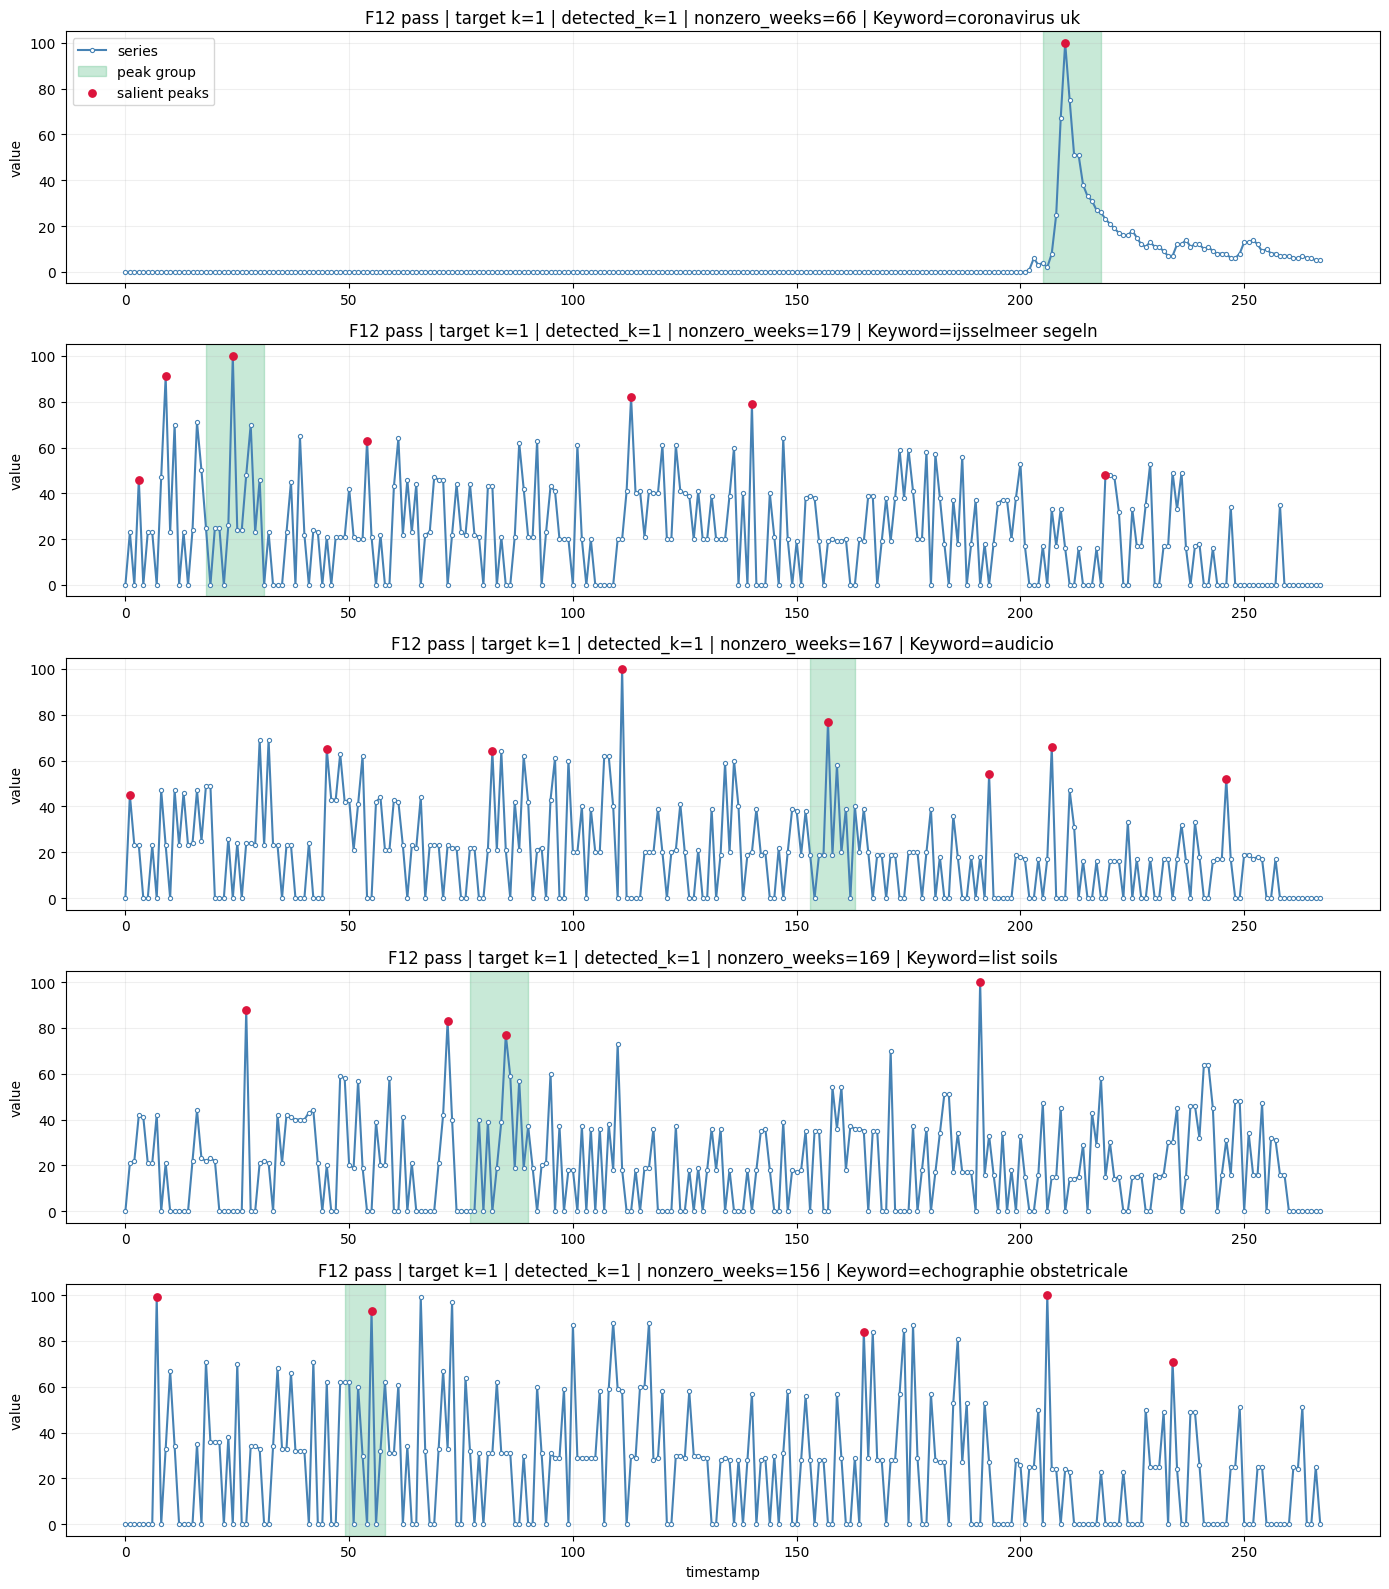

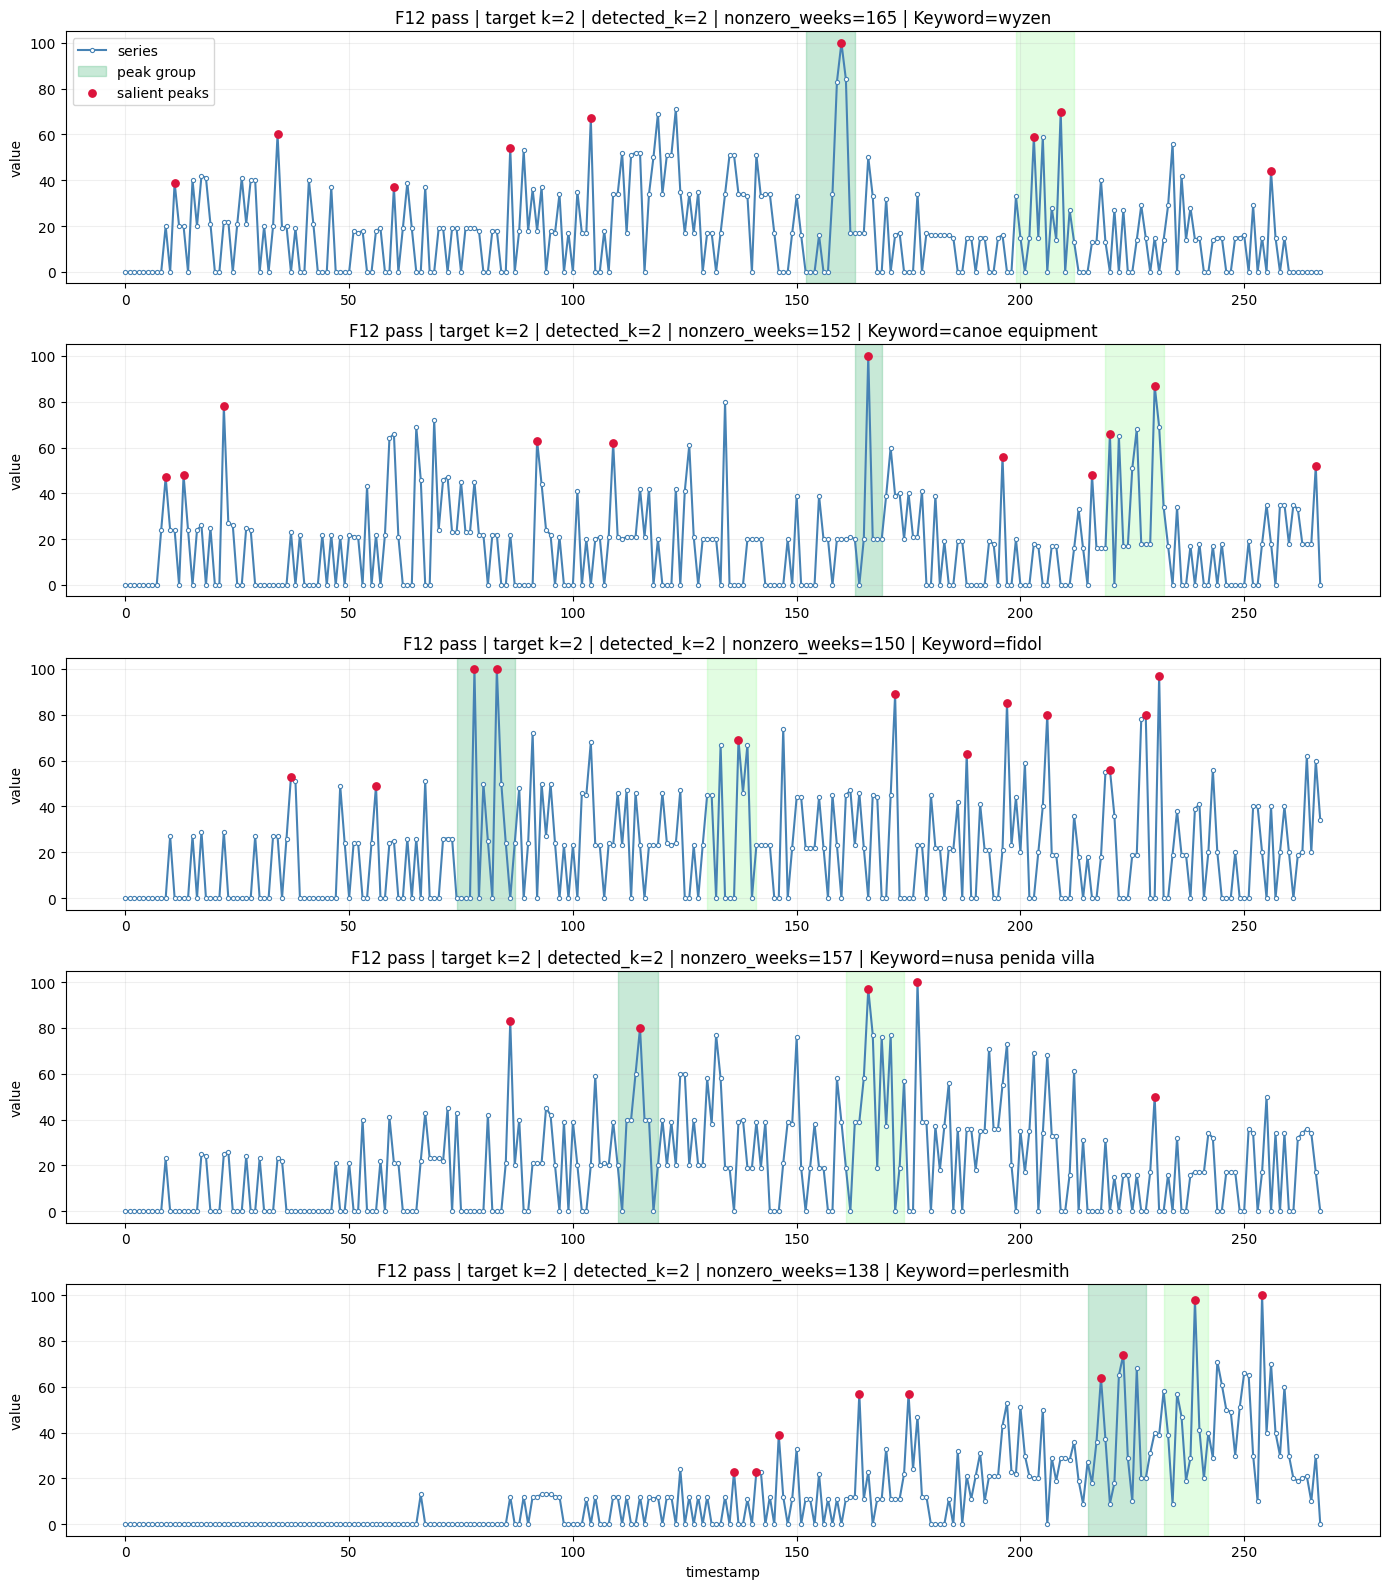

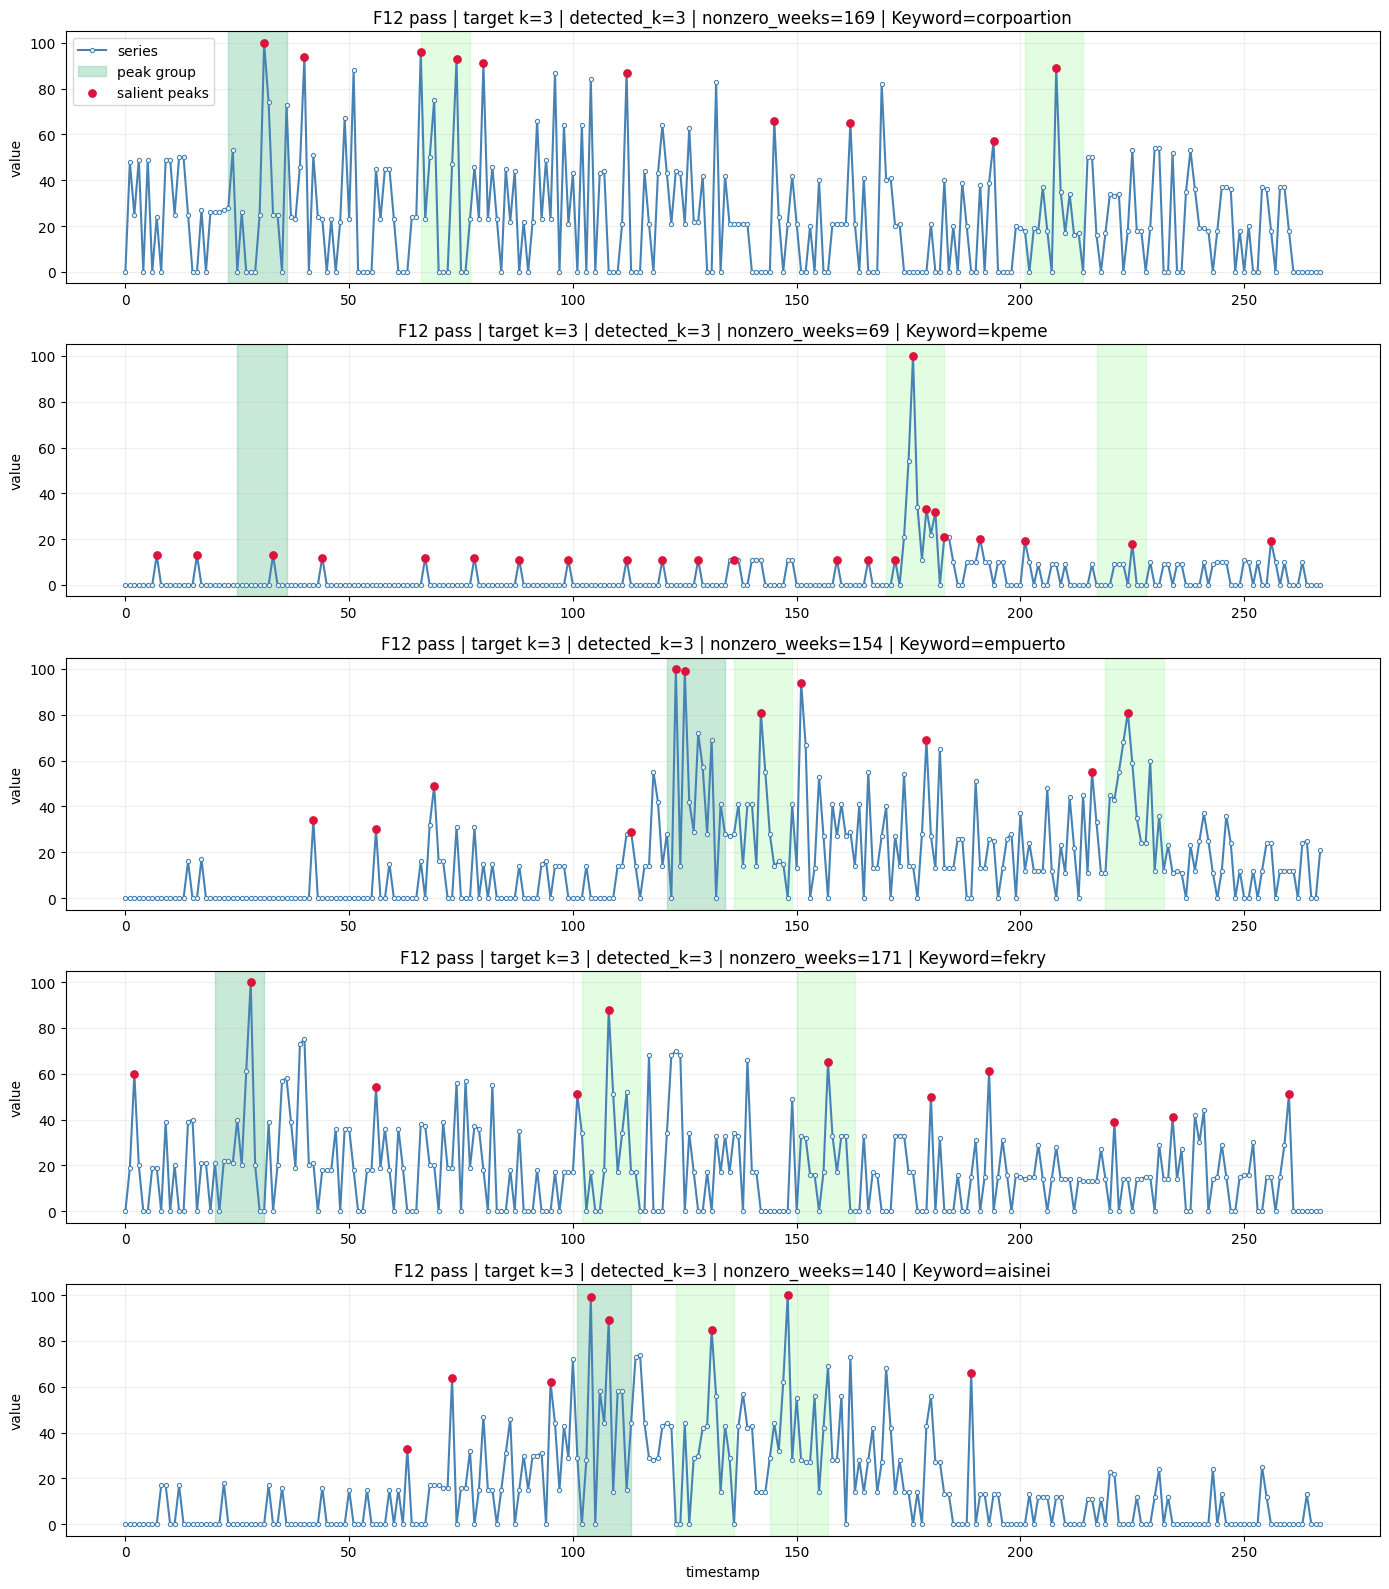

In [ ]:

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

N_SHOW_PER_K = 5
TARGET_KS = [1, 2, 3]
MAX_ALLOWED = 180.0
CONSEC_WEEKS = 6
RANDOM_STATE = 42


try:
    _ = DATA_PATH
    _ = OUT_ROOT
    _ = time_cols
except NameError:
    DIPLOM = Path(DIPLOM_DRIVE_DIR)
    DATA_PATH = DIPLOM / "dataset_without_non_empty_lt26.parquet"
    OUT_ROOT = DIPLOM / OUTPUT_DIR_NAME
    pf_tmp = pq.ParquetFile(DATA_PATH)
    time_cols = _time_cols(pf_tmp)

if not OUT_ROOT.is_dir():
    raise FileNotFoundError(f"Не найдена папка с разметкой k=*: {OUT_ROOT}")


def _pick_key_cols_from_k_parts(root: Path) -> list[str]:
    preferred = ["keyword_id", "series_id", "id", "Keyword", "keyword", "query", "word"]
    for k_dir in sorted(root.glob("k=*")):
        part_files = sorted(k_dir.glob("part-*.parquet"))
        if not part_files:
            continue
        cols = pq.read_schema(part_files[0]).names
        keys = [c for c in preferred if c in cols]
        if keys:
            return keys[:2]
        fallback = [c for c in cols if c not in {"k", "n_green_peak_groups"}]
        if fallback:
            return fallback[:2]
    raise ValueError("Не удалось определить key_cols из k-partitions")


key_cols = _pick_key_cols_from_k_parts(OUT_ROOT)

# key -> k
k_map = {}
for k_dir in sorted([p for p in OUT_ROOT.glob("k=*") if p.is_dir()], key=lambda p: p.name):
    try:
        kval = int(k_dir.name.split("=", 1)[1])
    except Exception:
        continue
    if kval not in TARGET_KS:
        continue
    for fp in sorted(k_dir.glob("part-*.parquet")):
        cols = set(pq.read_schema(fp).names)
        if not all(c in cols for c in key_cols):
            continue
        dfk = pd.read_parquet(fp, columns=key_cols)
        keys = list(zip(*[dfk[c].astype(str).tolist() for c in key_cols]))
        for key in keys:
            if key not in k_map:
                k_map[key] = kval

print("key_cols:", key_cols)
print("k_map size for target ks:", len(k_map))


pf_src = pq.ParquetFile(DATA_PATH)
cols_for_scan = key_cols + time_cols

candidates_by_k = {k: [] for k in TARGET_KS}
seen = set()

for rg in tqdm(range(pf_src.num_row_groups), desc="find F12 for k=1,2,3", unit="rg"):
    df = pf_src.read_row_group(rg, columns=cols_for_scan).to_pandas()
    if df.empty:
        continue

    arr = df[time_cols].to_numpy(dtype=np.float64, copy=False)
    arr_num = np.nan_to_num(arr, nan=0.0)

    nonzero_weeks = np.sum(arr_num > 0, axis=1)
    keep_f1 = nonzero_weeks <= MAX_ALLOWED

    nz = (arr_num > 0).astype(np.int8)
    if nz.shape[1] < CONSEC_WEEKS:
        keep_f2 = np.zeros(nz.shape[0], dtype=bool)
    else:
        cs = np.cumsum(nz, axis=1, dtype=np.int16)
        left = np.concatenate([np.zeros((nz.shape[0], 1), dtype=np.int16), cs[:, :-CONSEC_WEEKS]], axis=1)
        right = cs[:, CONSEC_WEEKS - 1 :]
        keep_f2 = np.any((right - left) == CONSEC_WEEKS, axis=1)

    keep_f12 = keep_f1 & keep_f2
    if not keep_f12.any():
        continue

    idxs = np.where(keep_f12)[0]
    for i in idxs:
        key = tuple(str(df.iloc[i][c]) for c in key_cols)
        if key in seen:
            continue
        kval = k_map.get(key)
        if kval not in TARGET_KS:
            continue
        seen.add(key)
        candidates_by_k[kval].append(
            {
                "key": key,
                "values": _prep(arr[i]),
                "nonzero_weeks": int(nonzero_weeks[i]),
            }
        )


    if all(len(candidates_by_k[k]) >= (N_SHOW_PER_K * 3) for k in TARGET_KS):
        break

for k in TARGET_KS:
    print(f"k={k}: candidates={len(candidates_by_k[k])}")

rng = np.random.default_rng(RANDOM_STATE)

for k in TARGET_KS:
    cand = candidates_by_k[k]
    if not cand:
        print(f"k={k}: нет F12-кандидатов")
        continue

    take = min(N_SHOW_PER_K, len(cand))
    picked_idx = rng.choice(len(cand), size=take, replace=False)
    picked = [cand[int(i)] for i in picked_idx]

    fig, axes = plt.subplots(take, 1, figsize=(14, 3.2 * take), sharex=False)
    if take == 1:
        axes = [axes]

    for ax, item in zip(axes, picked):
        values = item["values"]
        out = run_detection_pipeline(values)
        groups = out["groups"]
        salient = out["salient_peaks"]

        x = np.arange(values.size)
        ax.plot(x, values, color="steelblue", linewidth=1.5, marker="o", markersize=3,
                markerfacecolor="white", markeredgewidth=0.8, label="series")

        for gi, g in enumerate(groups):
            color = "mediumseagreen" if gi == 0 else "palegreen"
            label = "peak group" if gi == 0 else None
            ax.axvspan(g.start, g.end, color=color, alpha=0.28, label=label, zorder=1)

        if len(salient):
            ax.scatter(salient, values[salient], color="crimson", s=28, zorder=3, label="salient peaks")

        key_text = " | ".join([f"{c}={v}" for c, v in zip(key_cols, item["key"])])
        ax.set_title(
            f"F12 pass | target k={k} | detected_k={len(groups)} | nonzero_weeks={item['nonzero_weeks']} | {key_text}"
        )
        ax.set_ylabel("value")
        ax.grid(alpha=0.2)

    axes[0].legend(loc="upper left")
    axes[-1].set_xlabel("timestamp")
    fig.tight_layout()
    display(fig)
    plt.close(fig)
